In [1]:
# BASIC STEPS

!pip install transformers
!pip install opencv-python
!pip install tensorboard
!pip install timm

import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
from torchvision import models, transforms
import time
from transformers import CLIPModel, CLIPProcessor, ViTModel, ViTFeatureExtractor
import numpy as np
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
from timm import create_model
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import shutil
import random
from pathlib import Path




from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [2]:
# Counting for Checking

# Base path where your split dataset is stored
mel_dir = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input/Melanoma'
ben_dir = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input/Benign'

# Count function
def count_images(folder):
    valid_exts = ('.jpg', '.jpeg', '.png')
    return len([f for f in os.listdir(folder) if f.lower().endswith(valid_exts)])

# Count and print
mel_count = count_images(mel_dir)
ben_count = count_images(ben_dir)

print(f"Melanoma: {mel_count}")
print(f"Benign: {ben_count}")

Melanoma: 20809
Benign: 20809


Total: 53882 | Train: 45800 | Val: 8082


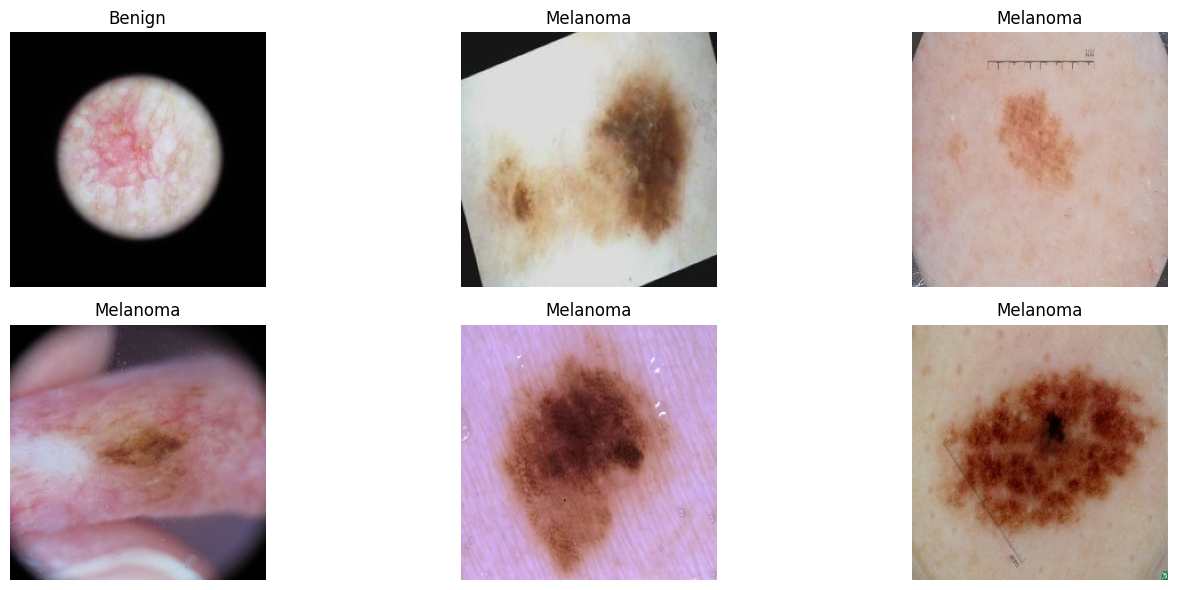

ISIC 2020 images: 44806
ISIC 2019 images: 41618
Combined total: 86424


In [2]:
# Loading Data

from torch.utils.data import random_split
from glob import glob
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Config
ISIC_2020_PATH = '/content/drive/MyDrive/THESIS/Dataset/kaggle/train'
ISIC_2019_PATH = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized'
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 12
VAL_SPLIT = 0.15
CLASS_NAMES = ['Benign', 'Melanoma']

# Dataset Class
class ISICCombinedDataset(Dataset):
    def __init__(self, isic2020_root, isic2019_root, transform=None):
        self.samples = []
        self.transform = transform

        # Add ISIC 2020 samples
        for label, cls in enumerate(CLASS_NAMES):
            folder = os.path.join(isic2020_root, cls)
            image_paths = glob(os.path.join(folder, '*.jpg'))
            self.samples += [(img_path, label) for img_path in image_paths]

        # Add ISIC 2019 samples
        for label, cls in enumerate(CLASS_NAMES):
            folder = os.path.join(isic2019_root, cls)
            image_paths = glob(os.path.join(folder, '*.jpg'))
            self.samples += [(img_path, label) for img_path in image_paths]


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = cv2.imread(path)  # uint8, 0-255
        if image is None:
            raise RuntimeError(f"Could not read image at {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']  # Albumentations expects uint8 input

        return image, torch.tensor(label, dtype=torch.long)


# Transforms
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Load dataset
combined_dataset = ISICCombinedDataset(
    isic2020_root=ISIC_2020_PATH,
    isic2019_root=ISIC_2019_PATH,
    transform=transform
)

# Train/Val Split
total_size = len(combined_dataset)
val_size = int(total_size * VAL_SPLIT)
train_size = total_size - val_size

train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Total: {total_size} | Train: {train_size} | Val: {val_size}")

# Visualization
def denormalize(image_tensor):
    image_tensor = image_tensor * 0.5 + 0.5  # reverse Normalize(mean=0.5, std=0.5)
    return image_tensor.clamp(0, 1)

def visualize_samples(dataset, num_images=6):
    indices = random.sample(range(len(dataset)), num_images)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img = denormalize(img_tensor).permute(1, 2, 0).numpy()
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(CLASS_NAMES[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# View samples from training set
visualize_samples(train_dataset)

def count_images(path, classes=['Benign','Melanoma']):
    total = 0
    for cls in classes:
        folder = os.path.join(path, cls)
        total += len([f for f in os.listdir(folder) if f.lower().endswith('.jpg')])
    return total

print("ISIC 2020 images:", count_images(ISIC_2020_PATH))
print("ISIC 2019 images:", count_images(ISIC_2019_PATH))
print("Combined total:", count_images(ISIC_2020_PATH) + count_images(ISIC_2019_PATH))

In [3]:
import os
import torch
import torch.nn as nn
import timm
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torchvision.models import (
    resnet50, ResNet50_Weights,
    efficientnet_b4, EfficientNet_B4_Weights,
    densenet201, DenseNet201_Weights
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['Benign', 'Melanoma']

def get_model(backbone_name):
    if backbone_name == 'resnet':
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Identity()
    elif backbone_name == 'efficientnet':
        model = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Identity()
    elif backbone_name == 'densenet':
        model = densenet201(weights=DenseNet201_Weights.DEFAULT)
        in_features = model.classifier.in_features
        model.classifier = nn.Identity()
    elif backbone_name == 'swin':
        model = timm.create_model('swin_base_patch4_window7_224', pretrained=True)
        in_features = model.head.in_features
        model.head = nn.Identity()
    else:
        raise ValueError(f"Unknown backbone {backbone_name}")

    classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, len(CLASS_NAMES))
    )

    class FullModel(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head = head

        def forward(self, x):
            features = self.backbone(x)
            return self.head(features)

    return FullModel(model, classifier).to(device)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, running_correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, running_correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss, running_correct, total = 0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            running_correct += (preds == labels).sum().item()
            total += imgs.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return running_loss / total, running_correct / total, y_true, y_pred

# Training settings
criterion = nn.CrossEntropyLoss()
backbones = ['resnet', 'efficientnet', 'densenet', 'swin']
best_models = {}
model_dir = "/content/drive/MyDrive/THESIS/Models"
os.makedirs(model_dir, exist_ok=True)

# Train loop
for backbone in backbones:
    print(f"\nTraining {backbone.upper()} model")
    model = get_model(backbone)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    best_val_acc = 0
    start_epoch = 1
    best_model_path = os.path.join(model_dir, f"best_{backbone}.pth")
    os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

    if os.path.exists(best_model_path):
        print(f"Resuming from checkpoint: {best_model_path}")
        checkpoint = torch.load(best_model_path, map_location=device)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            best_val_acc = checkpoint.get('best_val_acc', 0)
            start_epoch = checkpoint.get('epoch', 1)
            print(f"Loaded checkpoint with best_val_acc={best_val_acc:.4f}, starting from epoch {start_epoch}")
        else:
            model.load_state_dict(checkpoint)
            print("Loaded legacy model state_dict. Starting from epoch 1")
            best_val_acc = 0
            start_epoch = 1

    patience = 3
    epochs_no_improve = 0
    max_epochs = 10

    for epoch in range(start_epoch, max_epochs + 1):
        print(f"Epoch {epoch}/{max_epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion)
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'best_val_acc': best_val_acc
            }, best_model_path)
            print(f"Saved improved model for {backbone.upper()} at epoch {epoch}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping {backbone.upper()} at epoch {epoch}")
                break

    best_models[backbone] = best_model_path

    # Release memory for next model
    del model
    torch.cuda.empty_cache()


Training RESNET model


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


Resuming from checkpoint: /content/drive/MyDrive/THESIS/Models/best_resnet.pth
Loaded checkpoint with best_val_acc=0.9925, starting from epoch 3
Epoch 3/10


100%|██████████| 64/64 [08:25<00:00,  7.89s/it]


Train Loss: 0.0221 Acc: 0.9923 | Val Loss: 0.0188 Acc: 0.9936
Saved improved model for RESNET at epoch 3
Epoch 4/10


...

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Epoch 1/10


  0%|          | 0/358 [00:07<?, ?it/s]


RuntimeError: only batches of spatial targets supported (3D tensors) but got targets of size: : [128]

In [7]:
import os
import torch
import torch.nn as nn
import timm
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torchvision.models import (
    resnet50, ResNet50_Weights,
    efficientnet_b4, EfficientNet_B4_Weights,
    densenet201, DenseNet201_Weights
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['Benign', 'Melanoma']

def get_model(backbone_name):
    if backbone_name == 'resnet':
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Identity()
    elif backbone_name == 'efficientnet':
        model = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Identity()
    elif backbone_name == 'densenet':
        model = densenet201(weights=DenseNet201_Weights.DEFAULT)
        in_features = model.classifier.in_features
        model.classifier = nn.Identity()
    elif backbone_name == 'swin':
        model = timm.create_model('swin_small_patch4_window7_224', pretrained=True)
        # Remove the original head
        model.head = nn.Identity()

        # Add pooling and flattening for Swin output
        # Wrap the model and pooling/flattening in a Sequential to easily get output features
        backbone_with_pooling = nn.Sequential(
            model,
            nn.AdaptiveAvgPool2d((1, 1)),  # Converts [B, C, H, W] -> [B, C, 1, 1]
            nn.Flatten(1)             # -> [B, C]
        )
        # Move the sequential model to the device
        backbone_with_pooling.to(device)

        # Determine in_features dynamically
        dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
        with torch.no_grad():
            in_features = backbone_with_pooling(dummy_input).shape[1]

        model = backbone_with_pooling # Update model to include pooling and flattening

    else:
        raise ValueError(f"Unknown backbone {backbone_name}")

    classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, len(CLASS_NAMES))
    )

    class FullModel(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head = head

        def forward(self, x):
            features = self.backbone(x)
            return self.head(features)

    return FullModel(model, classifier).to(device)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, running_correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, running_correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss, running_correct, total = 0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            running_correct += (preds == labels).sum().item()
            total += imgs.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return running_loss / total, running_correct / total, y_true, y_pred

# === ONLY TRAIN SWIN ===
criterion = nn.CrossEntropyLoss()
backbone = 'swin'
model_dir = "/content/drive/MyDrive/THESIS/Models"
os.makedirs(model_dir, exist_ok=True)

print(f"\nTraining {backbone.upper()} model")
model = get_model(backbone)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

best_val_acc = 0
start_epoch = 1
best_model_path = os.path.join(model_dir, f"best_{backbone}.pth")

if os.path.exists(best_model_path):
    print(f"Resuming from checkpoint: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        best_val_acc = checkpoint.get('best_val_acc', 0)
        start_epoch = checkpoint.get('epoch', 1)
        print(f"Loaded checkpoint with best_val_acc={best_val_acc:.4f}, starting from epoch {start_epoch}")
    else:
        model.load_state_dict(checkpoint)
        print("Loaded legacy model state_dict. Starting from epoch 1")
        best_val_acc = 0
        start_epoch = 1

patience = 3
epochs_no_improve = 0
max_epochs = 10

for epoch in range(start_epoch, max_epochs + 1):
    print(f"Epoch {epoch}/{max_epochs}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'best_val_acc': best_val_acc
        }, best_model_path)
        print(f"Saved improved model for {backbone.upper()} at epoch {epoch}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping {backbone.upper()} at epoch {epoch}")
            break

del model
torch.cuda.empty_cache()


=== Training SWIN model ===
Epoch 1/10


100%|██████████| 506/506 [05:13<00:00,  1.61it/s]


Train Loss: 0.4317 Acc: 0.7916 | Val Loss: 0.3405 Acc: 0.8503
Saved improved model for SWIN at epoch 1
Epoch 2/10


100%|██████████| 506/506 [00:21<00:00, 23.63it/s]


Train Loss: 0.3129 Acc: 0.8547 | Val Loss: 0.2936 Acc: 0.8650
Saved improved model for SWIN at epoch 2
Epoch 3/10


...

Train Loss: 0.0794 Acc: 0.9716 | Val Loss: 0.2447 Acc: 0.9152
Saved improved model for SWIN at epoch 8
Epoch 9/10


100%|██████████| 506/506 [00:21<00:00, 23.63it/s]


Train Loss: 0.0354 Acc: 0.9884 | Val Loss: 0.3220 Acc: 0.9191
Saved improved model for SWIN at epoch 9
Epoch 10/10


100%|██████████| 506/506 [00:20<00:00, 24.42it/s]


Train Loss: 0.0262 Acc: 0.9920 | Val Loss: 0.3089 Acc: 0.9155


Test set size: 6580


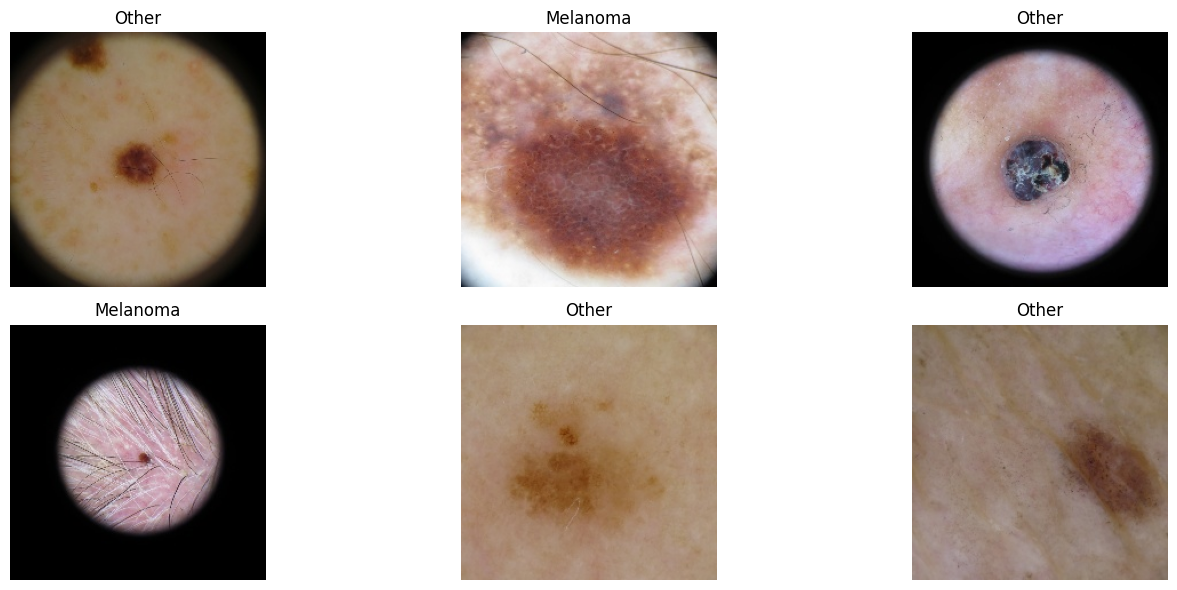

In [8]:
# Test Dataset Loader

# Required Imports

from glob import glob
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuration
ISIC_2019_TEST_PATH = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Normalized'
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 8
TEST_CLASS_NAMES = ['Other', 'Melanoma']  # label 0 = Other, 1 = Melanoma

# Transform (Matches training setup: [0,255] → [0,1] → [-1,1])
test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Dataset Class
class ISIC2019TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for label, cls in enumerate(TEST_CLASS_NAMES):
            cls_dir = os.path.join(root_dir, cls)
            image_paths = glob(os.path.join(cls_dir, '*.jpg'))
            self.samples += [(img_path, label) for img_path in image_paths]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = cv2.imread(path)
        if image is None:
            raise RuntimeError(f"Could not read image at {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)

# DataLoader
test_dataset = ISIC2019TestDataset(root_dir=ISIC_2019_TEST_PATH, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Test set size: {len(test_dataset)}")

# Denormalization (for visualization only)
def denormalize(tensor):
    tensor = tensor * 0.5 + 0.5
    return tensor.clamp(0, 1)

# Visualize Random Samples
def visualize_test_samples(dataset, num_images=6):
    indices = random.sample(range(len(dataset)), num_images)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img = denormalize(img_tensor).permute(1, 2, 0).numpy()
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(TEST_CLASS_NAMES[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# View Some Samples
visualize_test_samples(test_dataset)




=== Testing RESNET model ===


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 227MB/s]
Testing resnet: 100%|██████████| 206/206 [04:15<00:00,  1.24s/it]



Accuracy: 0.8698
Precision: 0.5786
Recall (Sensitivity): 0.6825
F1 Score: 0.6263

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.91      0.92      5528
    Melanoma       0.58      0.68      0.63      1052

    accuracy                           0.87      6580
   macro avg       0.76      0.79      0.77      6580
weighted avg       0.88      0.87      0.87      6580


Confusion Matrix:
[[5005  523]
 [ 334  718]]


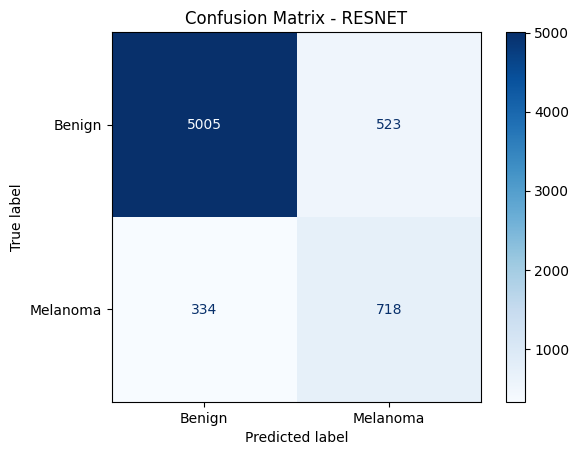

AUC: 0.8921


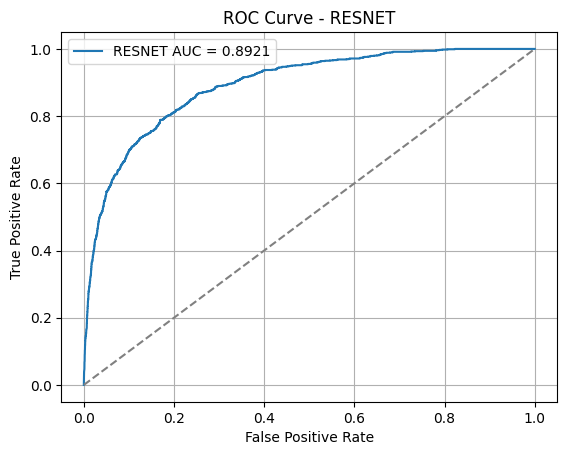


=== Testing EFFICIENTNET model ===


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:18<00:00, 4.24MB/s]
Testing efficientnet: 100%|██████████| 206/206 [00:17<00:00, 11.97it/s]



Accuracy: 0.8597
Precision: 0.5551
Recall (Sensitivity): 0.6179
F1 Score: 0.5848

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.91      0.92      5528
    Melanoma       0.56      0.62      0.58      1052

    accuracy                           0.86      6580
   macro avg       0.74      0.76      0.75      6580
weighted avg       0.87      0.86      0.86      6580


Confusion Matrix:
[[5007  521]
 [ 402  650]]


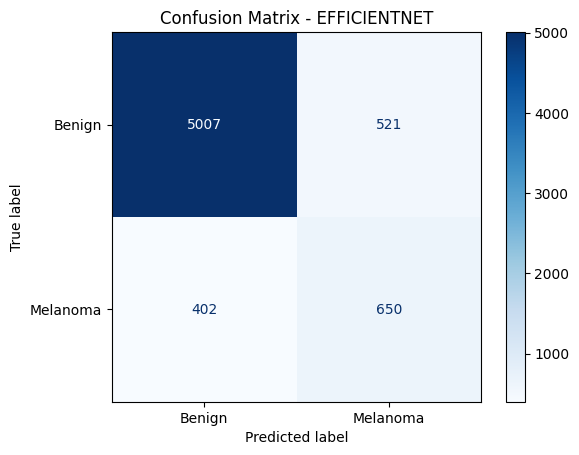

AUC: 0.8733


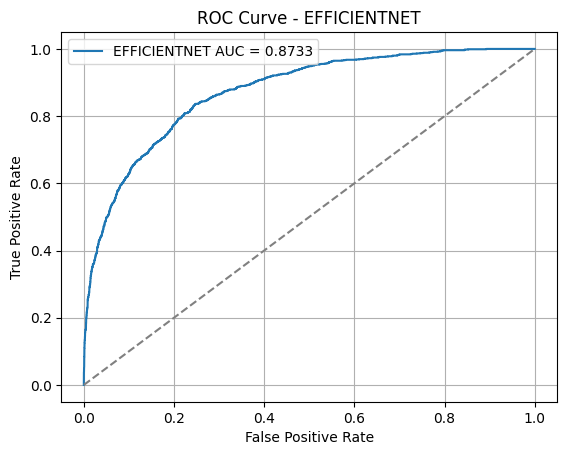


=== Testing DENSENET model ===


Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 199MB/s]
Testing densenet: 100%|██████████| 206/206 [00:17<00:00, 12.06it/s]



Accuracy: 0.8529
Precision: 0.5297
Recall (Sensitivity): 0.7129
F1 Score: 0.6078

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.88      0.91      5528
    Melanoma       0.53      0.71      0.61      1052

    accuracy                           0.85      6580
   macro avg       0.74      0.80      0.76      6580
weighted avg       0.88      0.85      0.86      6580


Confusion Matrix:
[[4862  666]
 [ 302  750]]


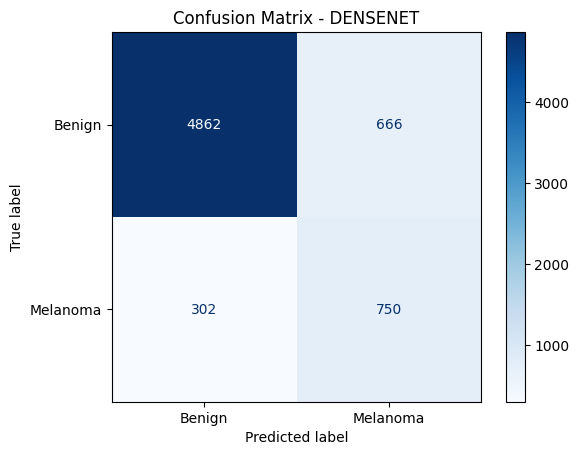

AUC: 0.8905


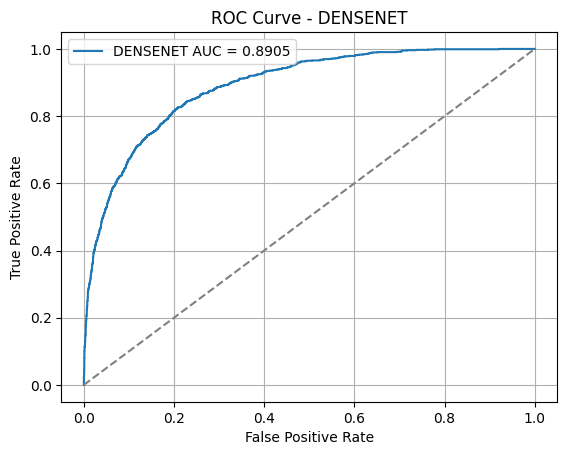


=== Testing SWIN model ===


Testing swin: 100%|██████████| 206/206 [00:17<00:00, 11.73it/s]



Accuracy: 0.8350
Precision: 0.4889
Recall (Sensitivity): 0.7091
F1 Score: 0.5787

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.86      0.90      5528
    Melanoma       0.49      0.71      0.58      1052

    accuracy                           0.83      6580
   macro avg       0.71      0.78      0.74      6580
weighted avg       0.87      0.83      0.85      6580


Confusion Matrix:
[[4748  780]
 [ 306  746]]


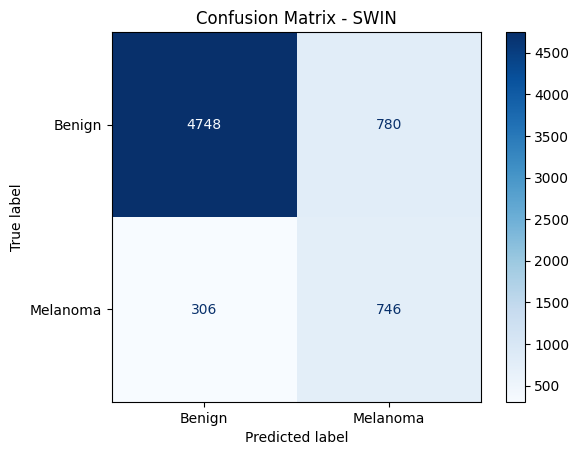

AUC: 0.8725


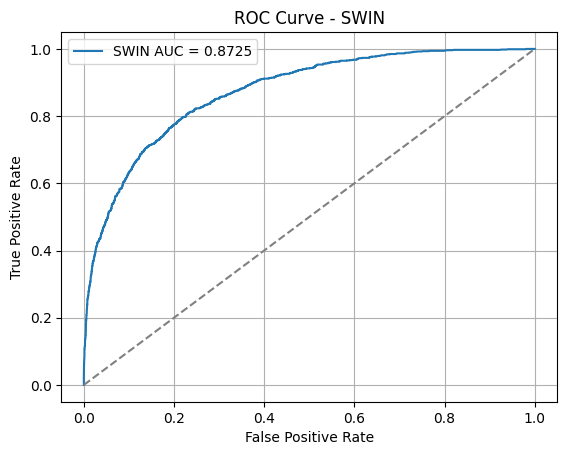

In [9]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['Benign', 'Melanoma']
THRESHOLD = 0.43

model_dir = "/content/drive/MyDrive/THESIS/Models"
backbones = ['resnet', 'efficientnet', 'densenet', 'swin']

for backbone in backbones:
    print(f"\nTesting {backbone.upper()} model")
    model = get_model(backbone)
    model_path = os.path.join(model_dir, f"best_{backbone}.pth")
    checkpoint = torch.load(model_path, map_location=device)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {backbone}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = (probs[:, 1] > THRESHOLD).long()

            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\nAccuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
    print("\nConfusion Matrix:")
    print(cm)

    # Plot Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {backbone.upper()}")
    plt.savefig(f"confusion_matrix_{backbone}.png")
    plt.show()

    # AUC and ROC
    try:
        auc = roc_auc_score(all_labels, all_probs)
        print(f"AUC: {auc:.4f}")

        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        plt.plot(fpr, tpr, label=f"{backbone.upper()} AUC = {auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {backbone.upper()}")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"roc_curve_{backbone}.png")
        plt.show()
    except Exception as e:
        print(f"AUC calculation failed: {e}")

    # Clean up
    del model
    torch.cuda.empty_cache()


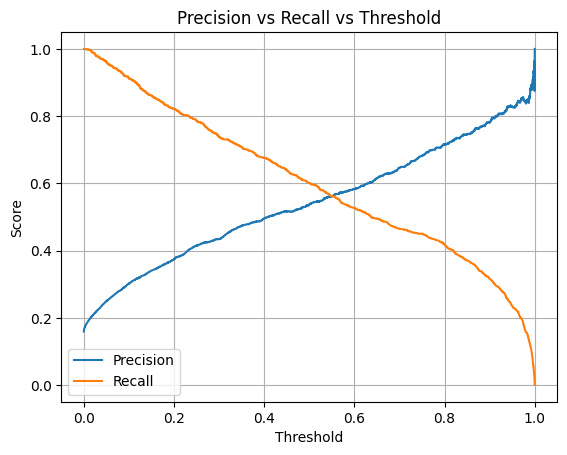

Best F1 score: 0.5747 at threshold 0.43


In [ ]:
from sklearn.metrics import precision_recall_curve
from numpy import argmax


precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()



f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = argmax(f1_scores)
print(f"Best F1 score: {f1_scores[best_idx]:.4f} at threshold {thresholds[best_idx]:.2f}")



Testing RESNET model


Testing resnet: 100%|██████████| 206/206 [00:16<00:00, 12.28it/s]



Accuracy: 0.8733
Precision: 0.5854
Recall (Sensitivity): 0.7101
F1 Score: 0.6418

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.90      0.92      5528
    Melanoma       0.59      0.71      0.64      1052

    accuracy                           0.87      6580
   macro avg       0.76      0.81      0.78      6580
weighted avg       0.89      0.87      0.88      6580


Confusion Matrix:
[[4999  529]
 [ 305  747]]


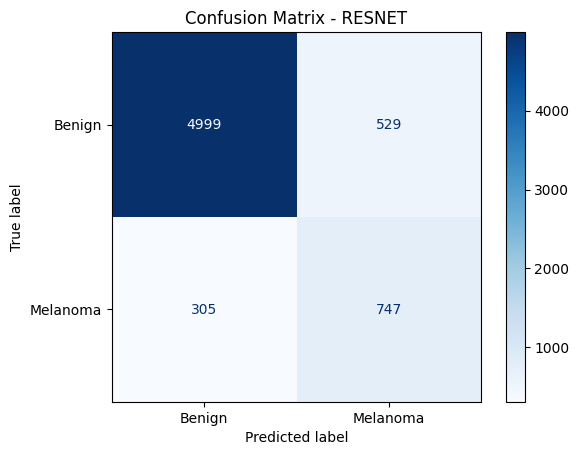

AUC: 0.9005


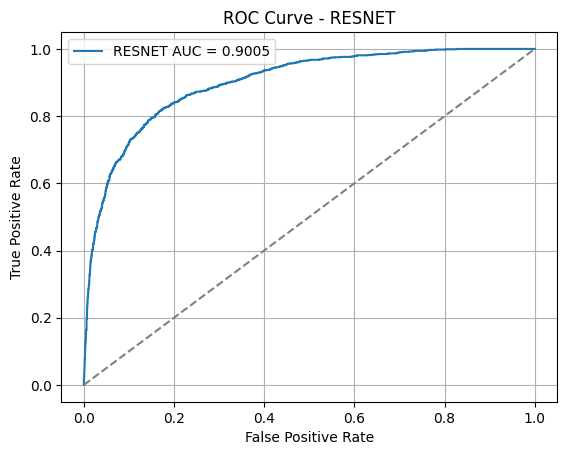


Testing EFFICIENTNET model


Testing efficientnet: 100%|██████████| 206/206 [00:19<00:00, 10.65it/s]



Accuracy: 0.8649
Precision: 0.5691
Recall (Sensitivity): 0.6378
F1 Score: 0.6015

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.91      0.92      5528
    Melanoma       0.57      0.64      0.60      1052

    accuracy                           0.86      6580
   macro avg       0.75      0.77      0.76      6580
weighted avg       0.87      0.86      0.87      6580


Confusion Matrix:
[[5020  508]
 [ 381  671]]


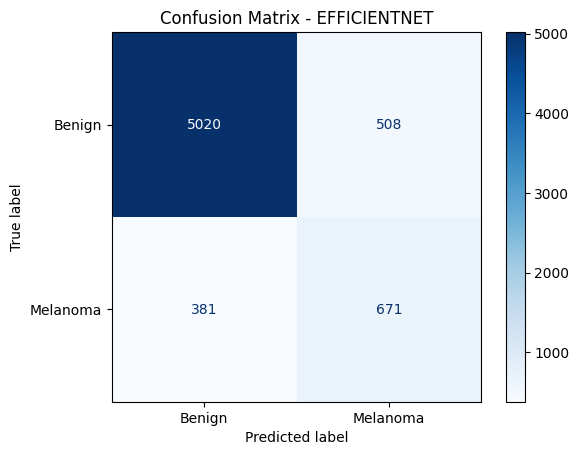

AUC: 0.8838


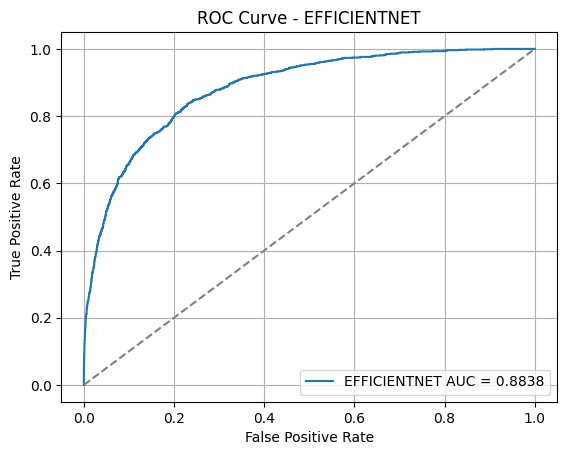


Testing DENSENET model


Testing densenet: 100%|██████████| 206/206 [00:28<00:00,  7.18it/s]



Accuracy: 0.8564
Precision: 0.5368
Recall (Sensitivity): 0.7414
F1 Score: 0.6228

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.88      0.91      5528
    Melanoma       0.54      0.74      0.62      1052

    accuracy                           0.86      6580
   macro avg       0.74      0.81      0.77      6580
weighted avg       0.88      0.86      0.87      6580


Confusion Matrix:
[[4855  673]
 [ 272  780]]


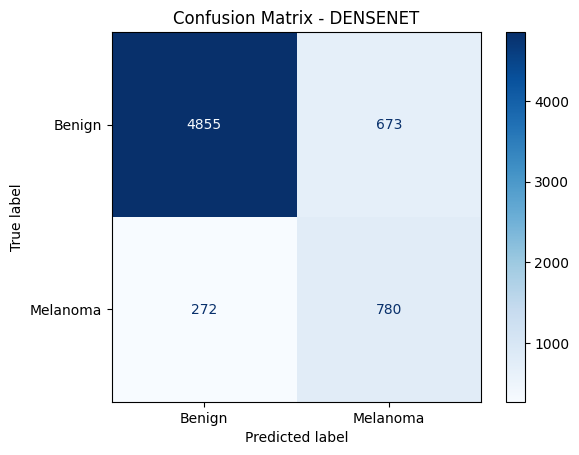

AUC: 0.9014


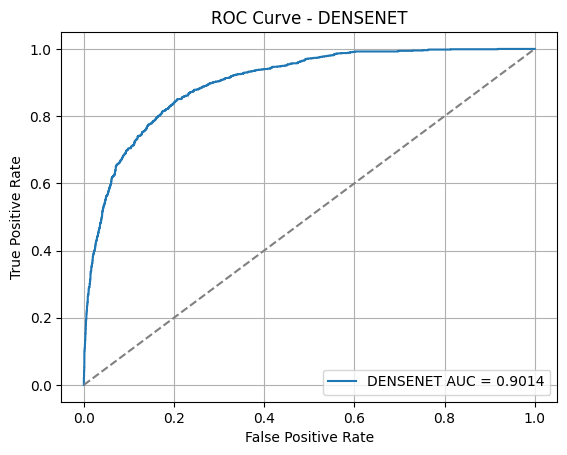


Testing SWIN model


Testing swin: 100%|██████████| 206/206 [00:34<00:00,  6.04it/s]



Accuracy: 0.8424
Precision: 0.5050
Recall (Sensitivity): 0.7205
F1 Score: 0.5938

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.87      0.90      5528
    Melanoma       0.50      0.72      0.59      1052

    accuracy                           0.84      6580
   macro avg       0.72      0.79      0.75      6580
weighted avg       0.87      0.84      0.85      6580


Confusion Matrix:
[[4785  743]
 [ 294  758]]


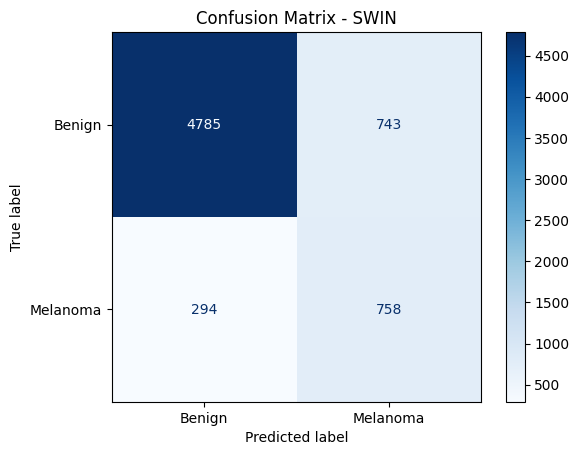

AUC: 0.8835


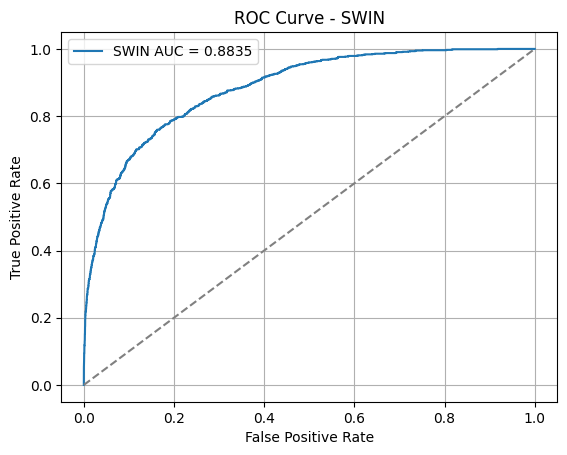

In [10]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import torchvision.transforms.functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['Benign', 'Melanoma']
THRESHOLD = 0.43

model_dir = "/content/drive/MyDrive/THESIS/Models"
backbones = ['resnet', 'efficientnet', 'densenet', 'swin']

def apply_tta(model, images):
    tta_preds = []

    # Original
    logits = model(images)
    tta_preds.append(torch.softmax(logits, dim=1))

    # Horizontal flip
    h_flip = TF.hflip(images)
    logits = model(h_flip)
    tta_preds.append(torch.softmax(logits, dim=1))

    # Vertical flip
    v_flip = TF.vflip(images)
    logits = model(v_flip)
    tta_preds.append(torch.softmax(logits, dim=1))

    # Average probabilities
    avg_probs = torch.stack(tta_preds).mean(dim=0)
    return avg_probs

for backbone in backbones:
    print(f"\nTesting {backbone.upper()} model")
    model = get_model(backbone)
    model_path = os.path.join(model_dir, f"best_{backbone}.pth")
    checkpoint = torch.load(model_path, map_location=device)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {backbone}"):
            images, labels = images.to(device), labels.to(device)
            probs = apply_tta(model, images)
            preds = (probs[:, 1] > THRESHOLD).long()

            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\nAccuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
    print("\nConfusion Matrix:")
    print(cm)

    # Plot Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {backbone.upper()}")
    plt.savefig(f"confusion_matrix_{backbone}.png")
    plt.show()

    # AUC and ROC
    try:
        auc = roc_auc_score(all_labels, all_probs)
        print(f"AUC: {auc:.4f}")

        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        plt.plot(fpr, tpr, label=f"{backbone.upper()} AUC = {auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {backbone.upper()}")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"roc_curve_{backbone}.png")
        plt.show()
    except Exception as e:
        print(f"AUC calculation failed: {e}")

    del model
    torch.cuda.empty_cache()
